## Direct Modulator — Sample 0 - correct

In [1]:
import gdsfactory as gf


def optical_direct_modulator():

    r = gf.Component()

    mzm = r.add_ref(gf.components.mzm(length_x=200))
    mzm.move((0, 0))

    straight = r.add_ref(gf.components.straight(length=10))
    straight.move((250, 0))

    routings = [
        (mzm.ports['o2'], straight.ports['o1']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip')

    r.add_port("o1", port=mzm.ports["o1"])
    r.add_port("o2", port=straight.ports["o2"])

    r.draw_ports()
    r.plot()

    return r

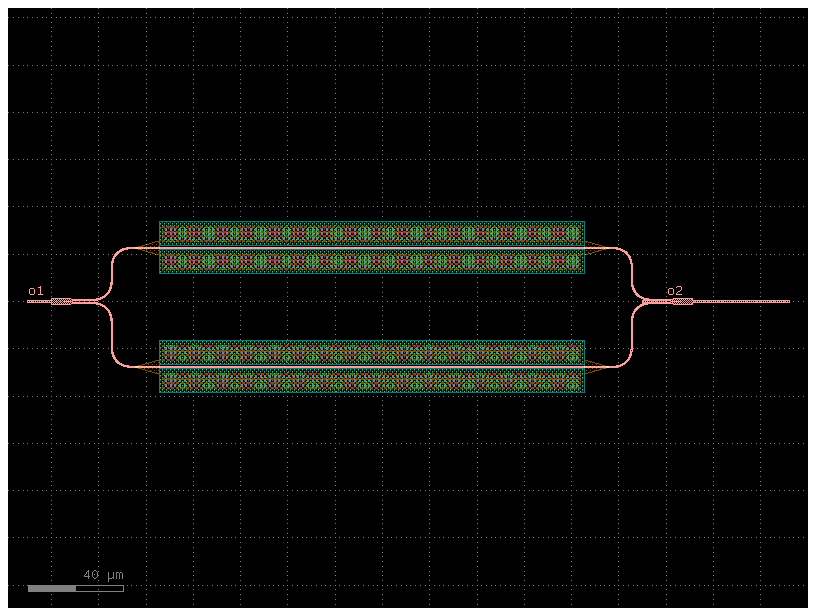

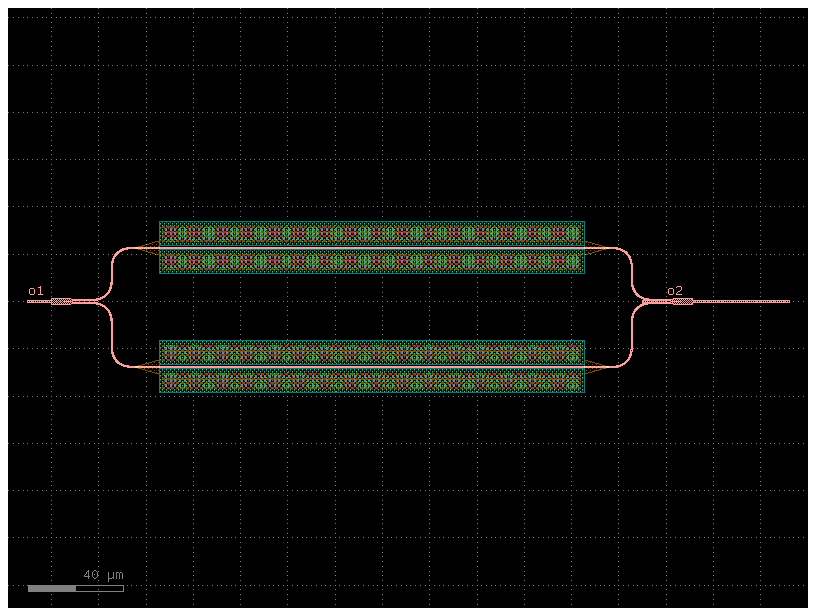

In [2]:
optical_direct_modulator()

## Direct Modulator — Sample 1 - correct

In [3]:

import gdsfactory as gf


def optical_direct_modulator1():

    r = gf.Component()

    mzm = r.add_ref(gf.components.mzm(length_x=200))
    mzm.move((0, 0))

    straight = r.add_ref(gf.components.straight(length=10))
    straight.move((250, 0))

    routings = [
        (mzm.ports['o2'], straight.ports['o1']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)

    r.add_port("o1", port=mzm.ports["o1"])
    r.add_port("o2", port=straight.ports["o2"])

    r.draw_ports()
    r.plot()

    return r


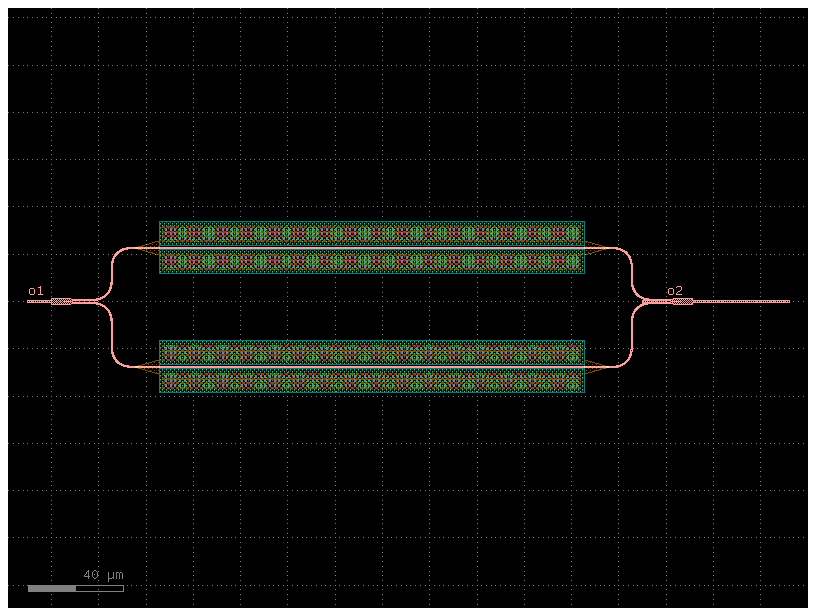

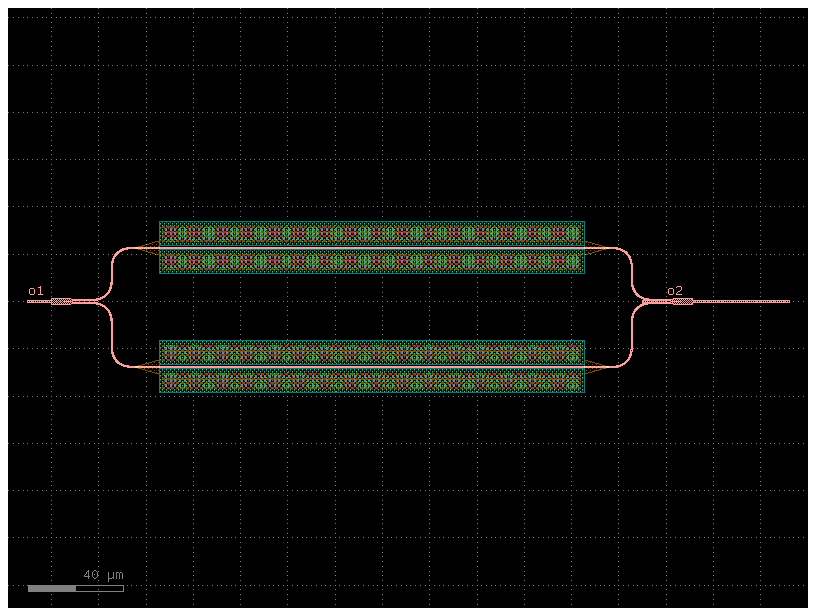

In [4]:
optical_direct_modulator1()

## Direct Modulator — Sample 2 - correct

In [6]:

import gdsfactory as gf


def optical_direct_modulator2():

    r = gf.Component()

    mzm = r.add_ref(gf.components.mzm(length_x=200))
    mzm.move((0, 0))

    straight = r.add_ref(gf.components.straight(length=10))
    straight.move((250, 0))

    routings = [
        (mzm.ports['o2'], straight.ports['o1']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)

    r.add_port("o1", port=mzm.ports["o1"])
    r.add_port("o2", port=straight.ports["o2"])

    r.draw_ports()
    r.plot()

    return r

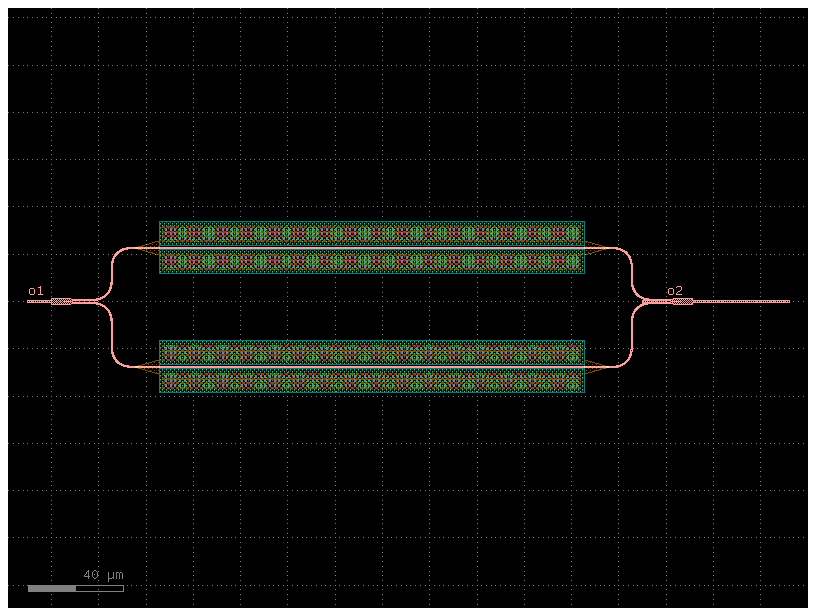

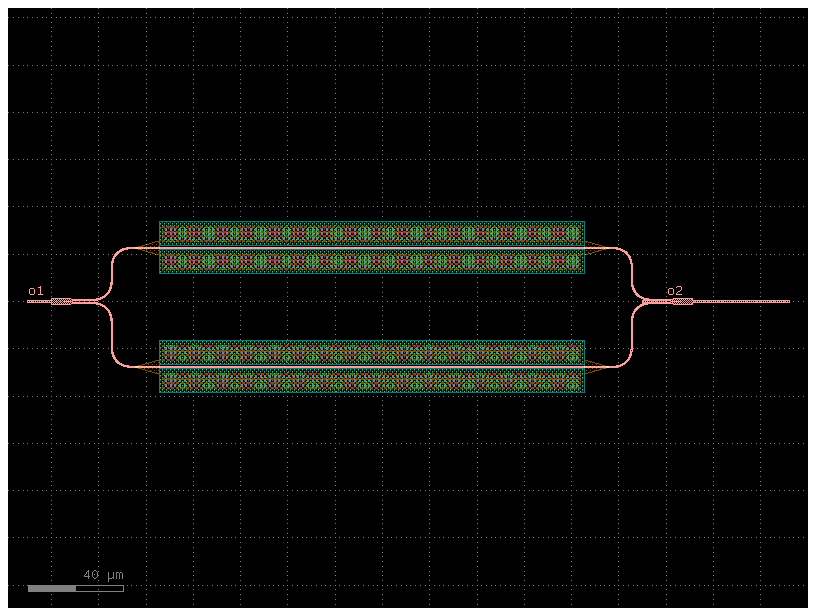

In [7]:
optical_direct_modulator2()

## 8-QAM Modulator — Sample 0 - func error (splitter 1 not connected to splitter 2)

In [13]:
import gdsfactory as gf


def optical_8qam_transmitter():

    r = gf.Component()

    # Instantiate all components
    splitter1 = r.add_ref(gf.components.mmi1x2())
    splitter2 = r.add_ref(gf.components.mmi1x2())

    combiner1 = r.add_ref(gf.components.mmi1x2())
    combiner2 = r.add_ref(gf.components.mmi1x2())
    # combiner1.reflect(p1=(0, 0), p2=(1, 0))
    # combiner2.reflect(p1=(0, 0), p2=(1, 0))

    combiner1.mirror()
    combiner2.mirror()

    mzm_bit1 = r.add_ref(gf.components.mzm(length_x=200))
    mzm_bit2 = r.add_ref(gf.components.mzm(length_x=200))
    mzm_bit3 = r.add_ref(gf.components.mzm(length_x=200))

    # Move parts to avoid overlap
    splitter1.move((0, 0))
    splitter2.move((0, 100))

    mzm_bit1.move((100, 0))
    mzm_bit2.move((100, 50))
    mzm_bit3.move((100, 100))

    combiner1.move((200, 50))
    combiner2.move((200, 150))

    # Connect ports with route_single
    routings = [
        (splitter1.ports['o2'], mzm_bit1.ports['o1']),
        (splitter1.ports['o3'], mzm_bit2.ports['o1']),
        (splitter2.ports['o2'], mzm_bit3.ports['o1']),
        (splitter2.ports['o3'], combiner2.ports['o2']),
        (mzm_bit1.ports['o2'], combiner1.ports['o2']),
        (mzm_bit2.ports['o2'], combiner1.ports['o3']),
        (mzm_bit3.ports['o2'], combiner2.ports['o3']),
        (combiner1.ports['o3'], combiner2.ports['o1']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)

    # Expose external ports
    r.add_port("o1", port=splitter1.ports["o1"])
    r.add_port("o2", port=combiner2.ports["o3"])

    r.draw_ports()
    r.plot()

    return r

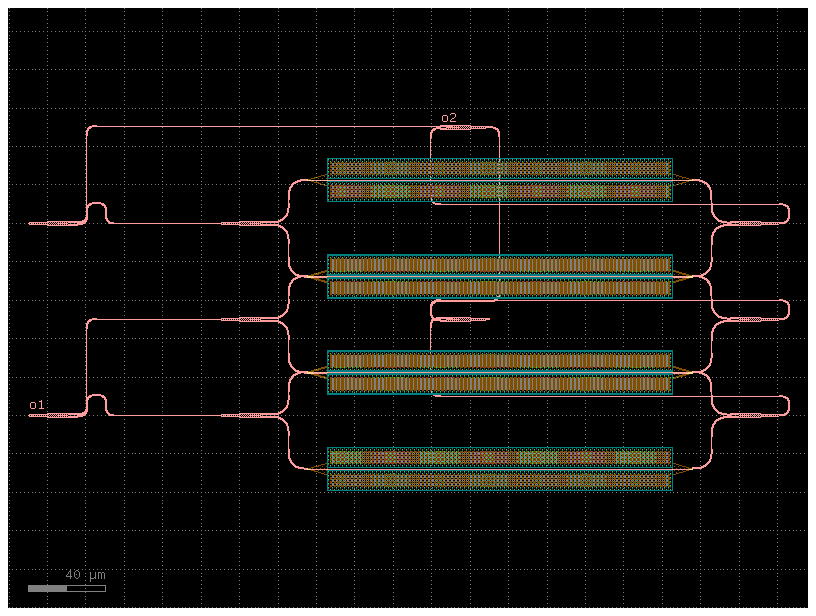

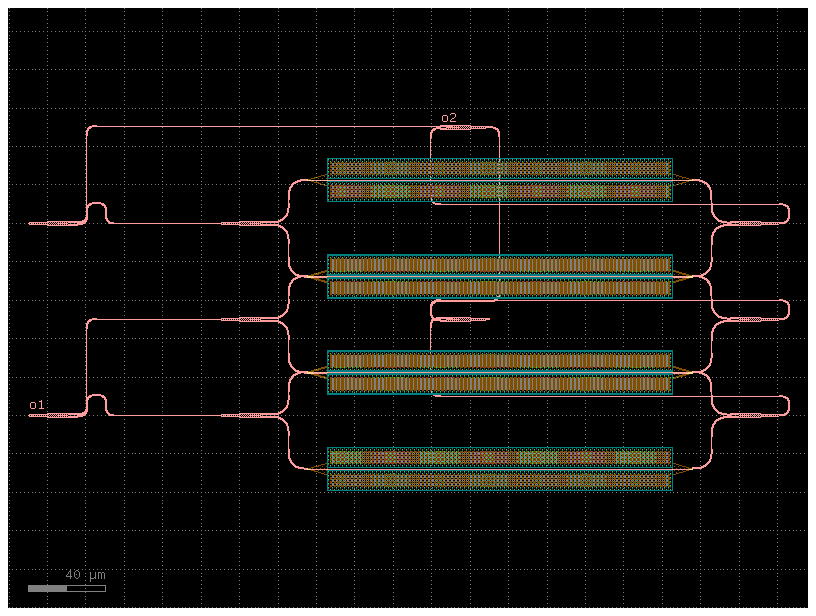

In [14]:
optical_8qam_transmitter()

## 8-QAM Modulator — Sample 1 - func error (splitter 1 not connected to splitter 2)

In [15]:

import gdsfactory as gf

def qam8_transmitter():
    c = gf.Component()

    # Instantiate all components
    splitter1 = c.add_ref(gf.components.mmi1x2())
    splitter2 = c.add_ref(gf.components.mmi1x2())
    combiner1 = c.add_ref(gf.components.mmi1x2())
    combiner2 = c.add_ref(gf.components.mmi1x2())
    mzm_bit1 = c.add_ref(gf.components.mzm(length_x=100))
    mzm_bit2 = c.add_ref(gf.components.mzm(length_x=100))
    mzm_bit3 = c.add_ref(gf.components.mzm(length_x=100))

    # Move parts to avoid overlap
    splitter1.move((0, 0))
    splitter2.move((0, 150))
    combiner1.move((300, 0))
    combiner2.move((300, 150))
    mzm_bit1.move((100, 50))
    mzm_bit2.move((100, 100))
    mzm_bit3.move((100, 150))

    # Connect ports with route_single
    routings = [
        (splitter1.ports['o2'], mzm_bit1.ports['o1']),
        (splitter1.ports['o3'], mzm_bit2.ports['o1']),
        (splitter2.ports['o2'], mzm_bit3.ports['o1']),
        (mzm_bit1.ports['o2'], combiner1.ports['o2']),
        (mzm_bit2.ports['o2'], combiner1.ports['o3']),
        (mzm_bit3.ports['o2'], combiner2.ports['o2']),
        (combiner1.ports['o1'], combiner2.ports['o3']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(c, port1=p1, port2=p2, cross_section='strip')

    # Expose external ports
    c.add_port("o1", port=splitter1.ports["o1"])
    c.add_port("o2", port=combiner2.ports["o1"])

    c.draw_ports()
    c.plot()

    return c

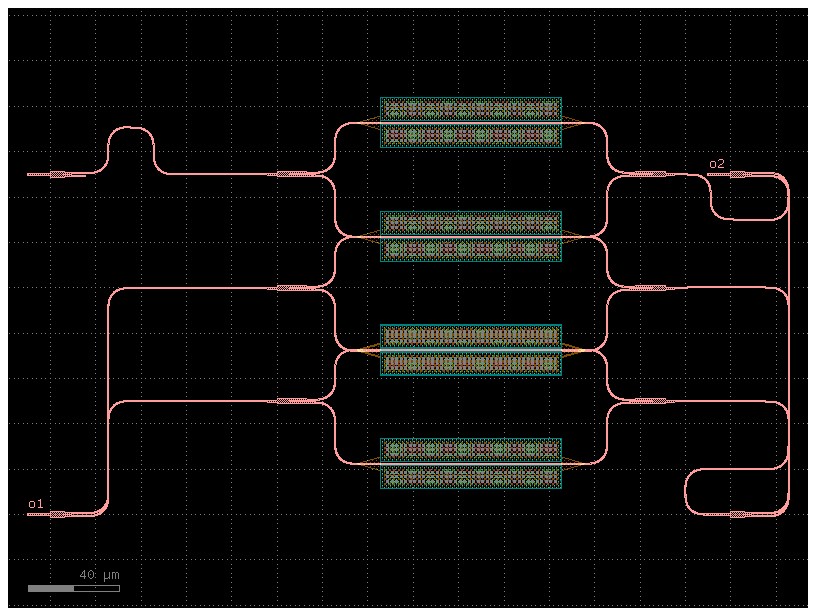

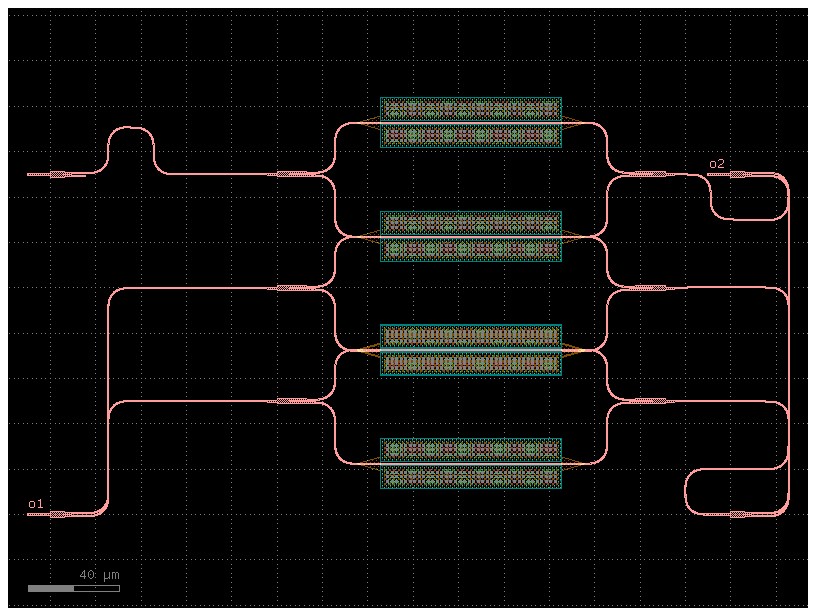

In [16]:
qam8_transmitter()

## 8-QAM Modulator — Sample 2 - func error (splitter 1 not connected to splitter 2)

In [17]:

import gdsfactory as gf

def optical_8qam_transmitter2():
    r = gf.Component()

    # Instantiate all components
    splitter1 = r.add_ref(gf.components.mmi1x2())
    splitter2 = r.add_ref(gf.components.mmi1x2())
    combiner1 = r.add_ref(gf.components.mmi1x2())
    combiner2 = r.add_ref(gf.components.mmi1x2())
    mzm_bit1 = r.add_ref(gf.components.mzm(length_x=200))
    mzm_bit2 = r.add_ref(gf.components.mzm(length_x=200))
    mzm_bit3 = r.add_ref(gf.components.mzm(length_x=200))

    # Move parts to avoid overlap
    splitter1.move((0, 0))
    splitter2.move((0, 150))
    combiner1.move((400, 0))
    combiner2.move((400, 150))
    mzm_bit1.move((100, 50))
    mzm_bit2.move((100, 100))
    mzm_bit3.move((100, 150))

    # Connect ports with route_single
    routings = [
        (splitter1.ports['o2'], mzm_bit1.ports['o1']),
        (splitter1.ports['o3'], mzm_bit2.ports['o1']),
        (splitter2.ports['o2'], mzm_bit3.ports['o1']),
        (mzm_bit1.ports['o2'], combiner1.ports['o2']),
        (mzm_bit2.ports['o2'], combiner1.ports['o3']),
        (mzm_bit3.ports['o2'], combiner2.ports['o2']),
        (combiner1.ports['o1'], combiner2.ports['o3']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip')

    # Expose external ports
    r.add_port("o1", port=splitter1.ports["o1"])
    r.add_port("o2", port=combiner2.ports["o1"])

    r.draw_ports()
    r.plot()

    return r

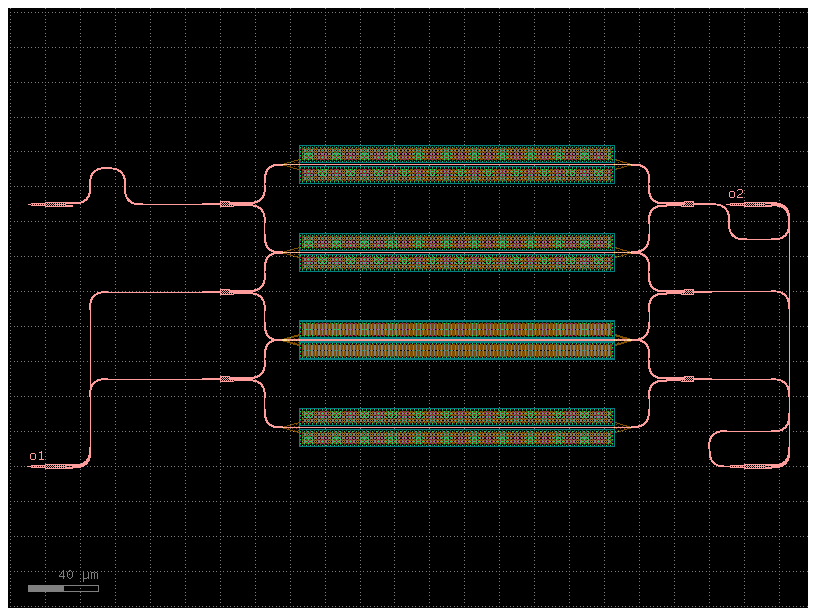

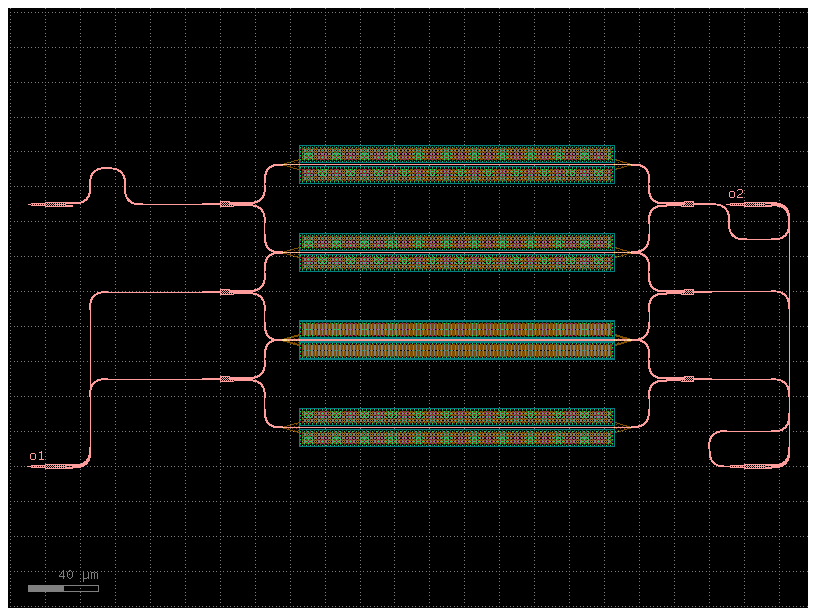

In [18]:
optical_8qam_transmitter2()

## Mach-Zehnder interferometer — Sample 0 - correct? needs to mirror mmi2

In [19]:

import gdsfactory as gf


def mzi_with_phase_shifter():
    r = gf.Component()

    # Instantiate all components
    mmi1 = r.add_ref(gf.components.mmi1x2())
    mmi2 = r.add_ref(gf.components.mmi1x2())
    waveguide = r.add_ref(gf.components.straight(length=10))
    phase_shifter = r.add_ref(gf.components.straight_heater_metal(length=10))

    # Move parts to avoid overlap
    mmi2.move((200, 0))
    waveguide.move((100, -20))
    phase_shifter.move((100, 20))

    # Connect ports with route_single
    routings = [
        (mmi1.ports['o2'], phase_shifter.ports['o1']),
        (mmi1.ports['o3'], waveguide.ports['o1']),
        (phase_shifter.ports['o2'], mmi2.ports['o2']),
        (waveguide.ports['o2'], mmi2.ports['o3']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)

    # Expose external ports
    r.add_port("o1", port=mmi1.ports["o1"])
    r.add_port("o2", port=mmi2.ports["o3"])

    r.draw_ports()
    r.plot()

    return r

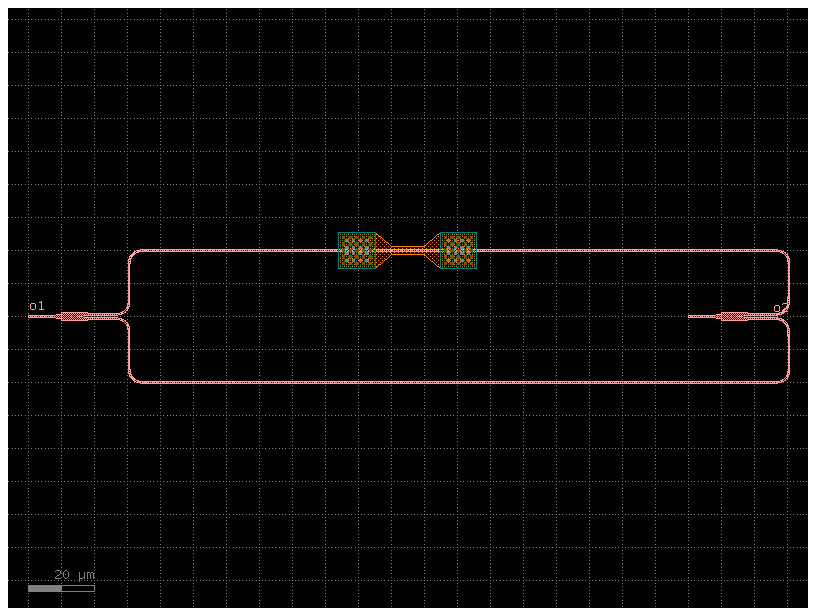

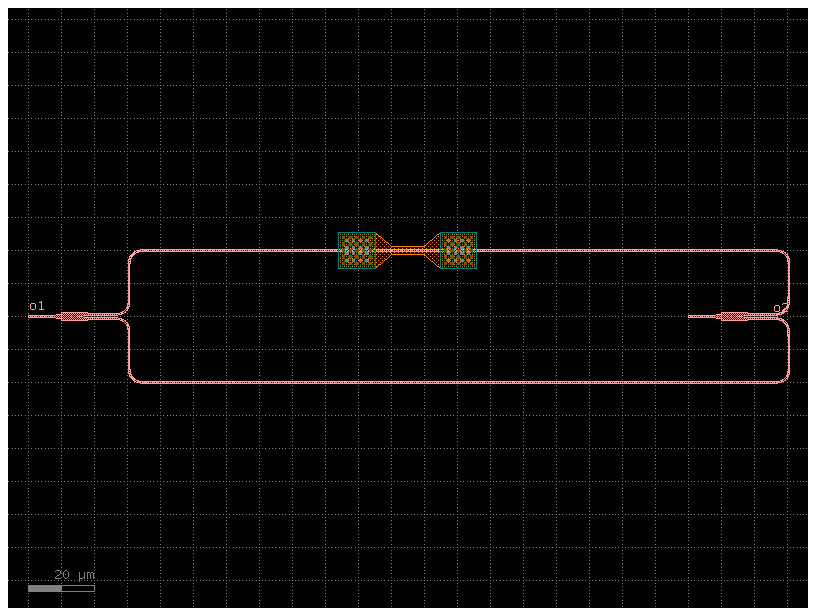

In [20]:
mzi_with_phase_shifter()

## Mach-Zehnder interferometer — Sample 1 - correct? weird port choice

In [22]:
import gdsfactory as gf


def mzi_with_phase_shifter1():
    r = gf.Component()

    mmi1 = r.add_ref(gf.components.mmi1x2())
    mmi1.move((0, 0))

    mmi2 = r.add_ref(gf.components.mmi1x2())
    mmi2.move((200, 0))

    waveguide = r.add_ref(gf.components.straight(length=10 + 10))
    waveguide.move((100, -20))

    phase_shifter = r.add_ref(gf.components.straight_heater_metal(length=10))
    phase_shifter.move((100, 20))

    routings = [
        (mmi1.ports['o2'], phase_shifter.ports['o1']),
        (mmi1.ports['o3'], waveguide.ports['o1']),
        (mmi2.ports['o2'], phase_shifter.ports['o2']),
        (mmi2.ports['o1'], waveguide.ports['o2']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)

    r.add_port("o1", port=mmi1.ports["o1"])
    r.add_port("o2", port=mmi2.ports["o3"])

    r.draw_ports()
    r.plot()

    return r

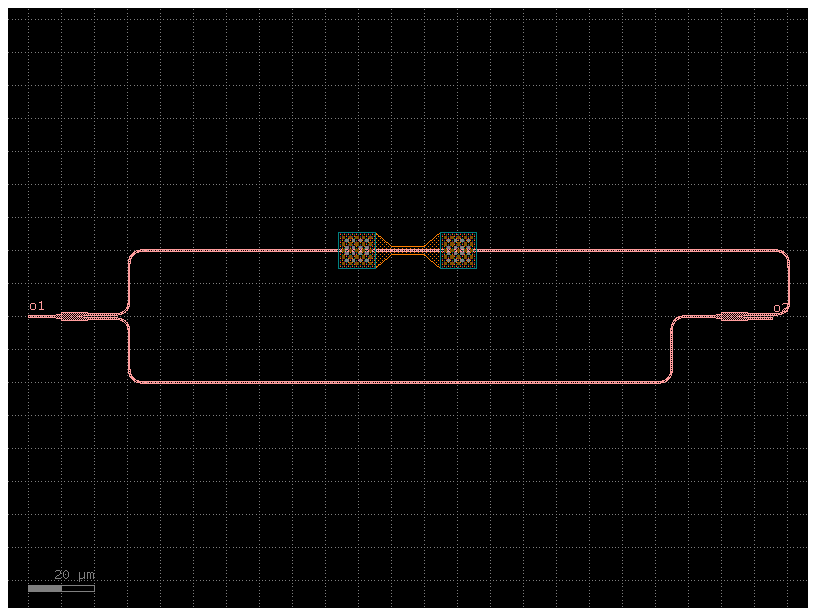

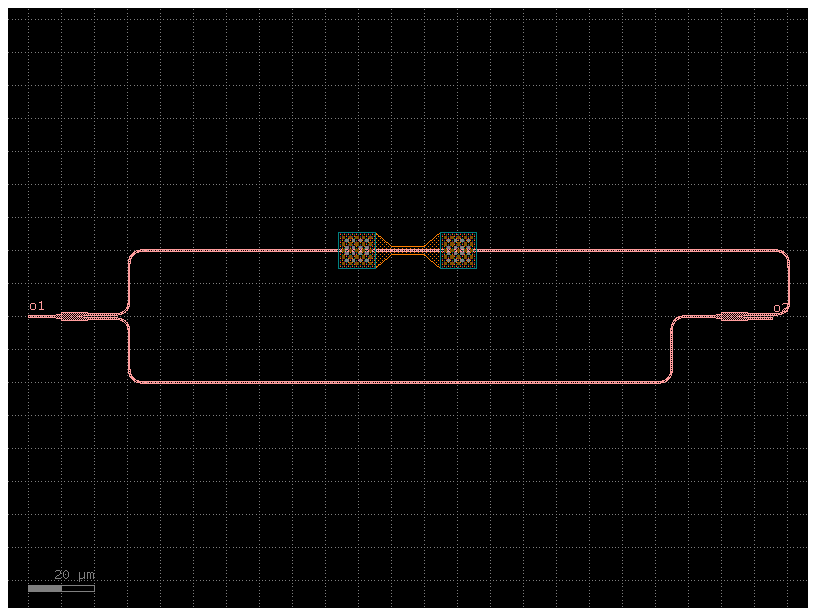

In [23]:
mzi_with_phase_shifter1()

## Mach-Zehnder interferometer — Sample 2 - correct? weird port choice

In [25]:
import gdsfactory as gf


def mzi_with_phase_shifter2():
    r = gf.Component()

    mmi1 = r.add_ref(gf.components.mmi1x2())
    mmi1.move((0, 0))

    mmi2 = r.add_ref(gf.components.mmi1x2())
    mmi2.move((200, 0))

    phase_shifter = r.add_ref(gf.components.straight_heater_metal(length=10))
    phase_shifter.move((100, 20))

    waveguide = r.add_ref(gf.components.straight(length=10 + 10))
    waveguide.move((100, -20))

    routings = [
        (mmi1.ports['o2'], phase_shifter.ports['o1']),
        (mmi1.ports['o3'], waveguide.ports['o1']),
        (mmi2.ports['o2'], phase_shifter.ports['o2']),
        (mmi2.ports['o1'], waveguide.ports['o2']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)

    r.add_port("o1", port=mmi1.ports["o1"])
    r.add_port("o2", port=mmi2.ports["o3"])

    r.draw_ports()
    r.plot()

    return r

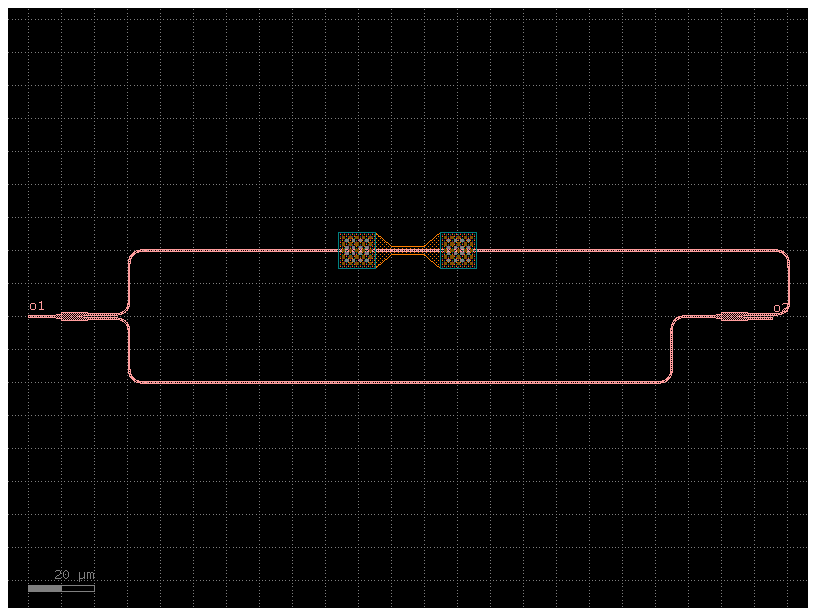

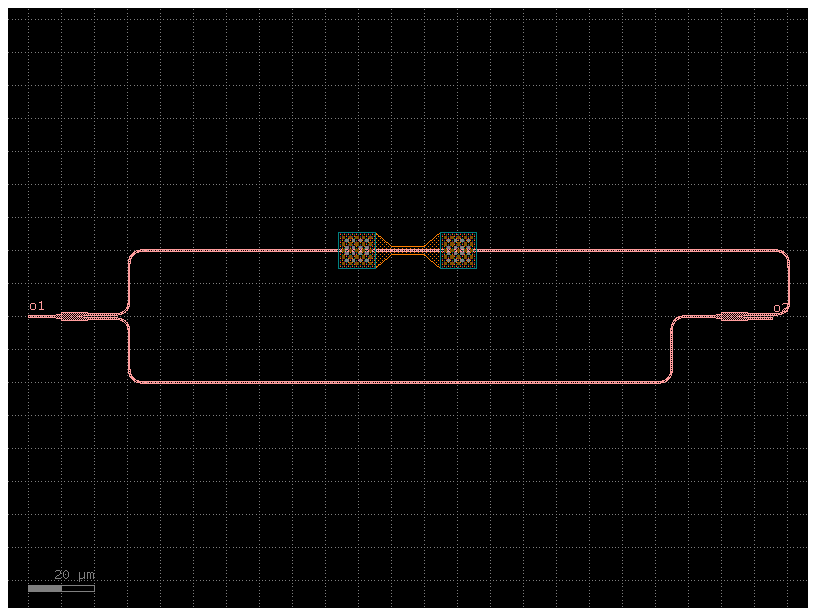

In [26]:
mzi_with_phase_shifter2()

## Mach-Zehnder Modulator — Sample 0 - correct (simple change: reflect -> mirror)

In [29]:
import gdsfactory as gf


def mzm_cell(L=10):

    r = gf.Component()

    splitter = r.add_ref(gf.components.mmi1x2())
    splitter.move((0, 0))

    combiner = r.add_ref(gf.components.mmi1x2())
    # combiner.reflect(p1=(0, 0), p2=(1, 0))
    combiner.mirror()
    combiner.move((200, 0))

    phase_shifter1 = r.add_ref(gf.components.straight_heater_metal(length=L))
    phase_shifter1.move((100, 20))

    phase_shifter2 = r.add_ref(gf.components.straight_heater_metal(length=L))
    phase_shifter2.move((100, -20))

    routings = [
        (splitter.ports['o2'], phase_shifter1.ports['o1']),
        (splitter.ports['o3'], phase_shifter2.ports['o1']),
        (combiner.ports['o2'], phase_shifter1.ports['o2']),
        (combiner.ports['o3'], phase_shifter2.ports['o2']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)

    r.add_port("o1", port=splitter.ports["o1"])
    r.add_port("o2", port=combiner.ports["o1"])

    r.draw_ports()
    r.plot()

    return r

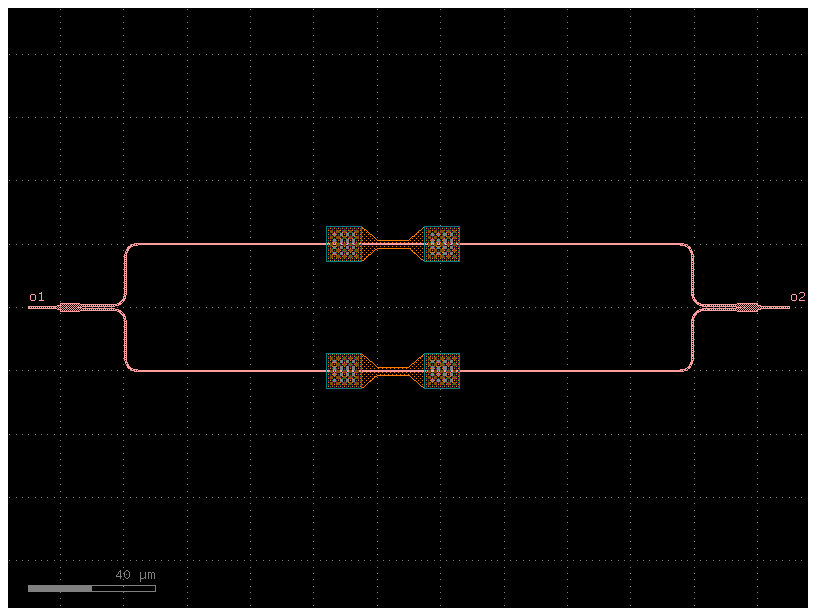

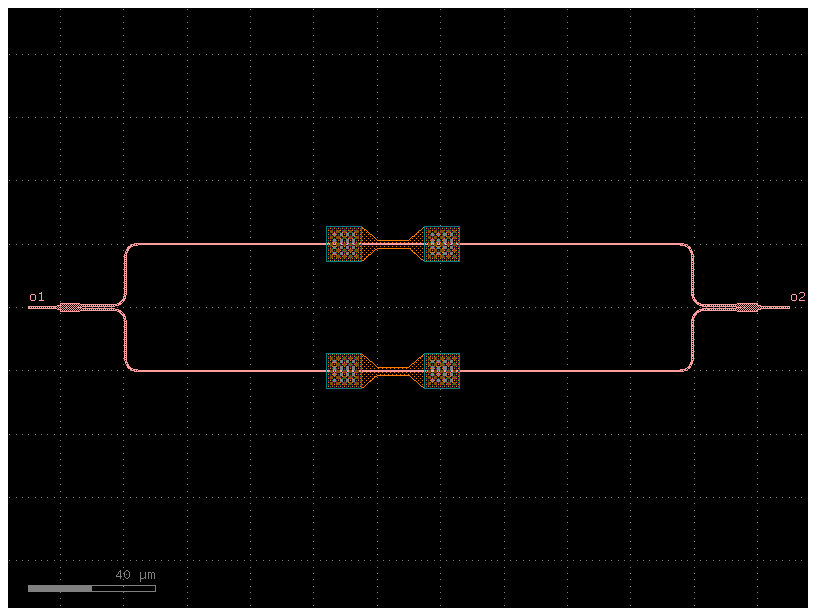

In [30]:
mzm_cell()

## Mach-Zehnder Modulator — Sample 1 - correct (simple change: reflect -> mirror)

In [32]:
import gdsfactory as gf


def mzm_cell1(L=10):
    r = gf.Component()

    splitter = r.add_ref(gf.components.mmi1x2())
    splitter.move((0, 0))

    combiner = r.add_ref(gf.components.mmi1x2())
    # combiner.reflect(p1=(0, 0), p2=(1, 0))
    combiner.mirror()
    combiner.move((200, 0))

    phase_shifter1 = r.add_ref(gf.components.straight_heater_metal(length=L))
    phase_shifter1.move((100, 20))

    phase_shifter2 = r.add_ref(gf.components.straight_heater_metal(length=L))
    phase_shifter2.move((100, -20))

    routings = [
        (splitter.ports['o2'], phase_shifter1.ports['o1']),
        (splitter.ports['o3'], phase_shifter2.ports['o1']),
        (combiner.ports['o2'], phase_shifter1.ports['o2']),
        (combiner.ports['o3'], phase_shifter2.ports['o2']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)

    r.add_port("o1", port=splitter.ports["o1"])
    r.add_port("o2", port=combiner.ports["o1"])

    r.draw_ports()
    r.plot()

    return r

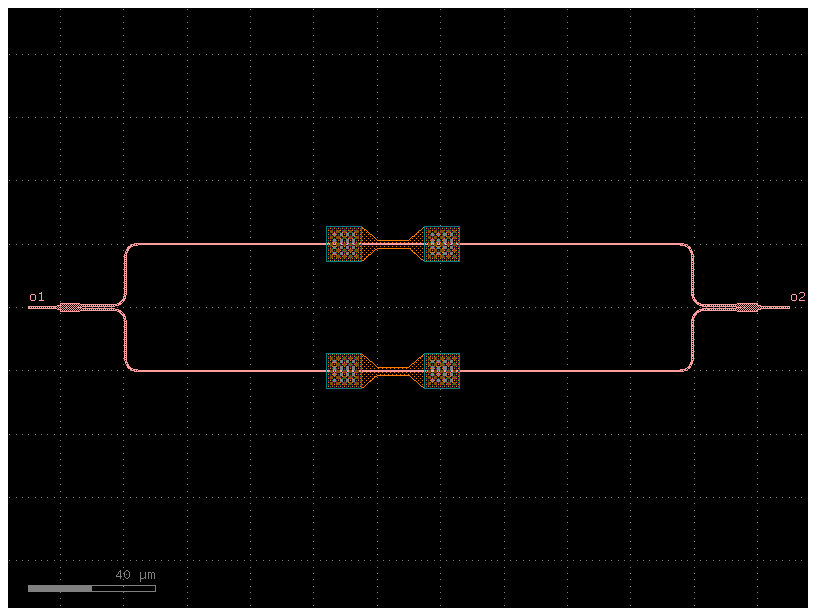

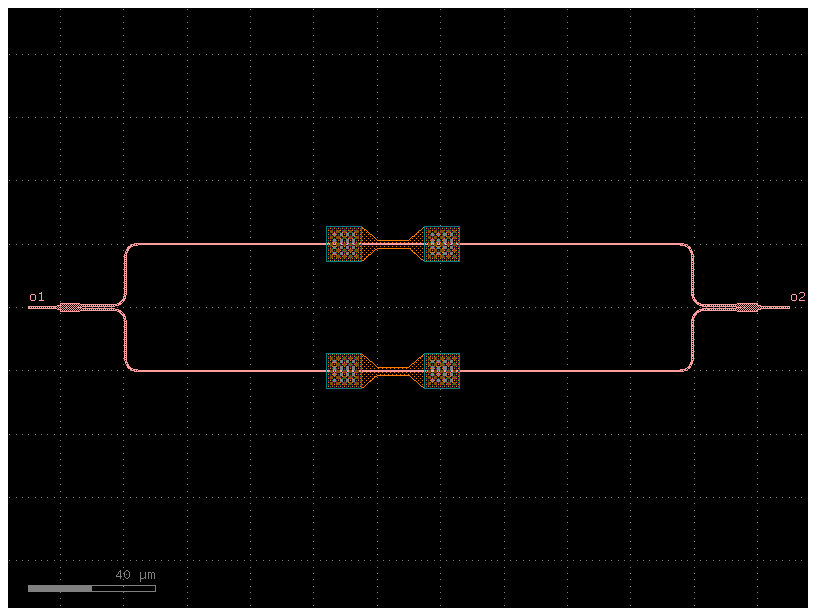

In [33]:
mzm_cell1()

## Mach-Zehnder Modulator — Sample 2 - correct (simple change: reflect -> mirror)

In [35]:
import gdsfactory as gf


def mzm_cell2(L=10):

    r = gf.Component()

    splitter = r.add_ref(gf.components.mmi1x2())
    splitter.move((0, 0))

    combiner = r.add_ref(gf.components.mmi1x2())
    # combiner.reflect(p1=(0, 0), p2=(1, 0))
    combiner.mirror()
    combiner.move((200, 0))

    phase_shifter1 = r.add_ref(gf.components.straight_heater_metal(length=L))
    phase_shifter1.move((100, 20))

    phase_shifter2 = r.add_ref(gf.components.straight_heater_metal(length=L))
    phase_shifter2.move((100, -20))

    routings = [
        (splitter.ports['o2'], phase_shifter1.ports['o1']),
        (splitter.ports['o3'], phase_shifter2.ports['o1']),
        (combiner.ports['o2'], phase_shifter1.ports['o2']),
        (combiner.ports['o3'], phase_shifter2.ports['o2']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)

    r.add_port("o1", port=splitter.ports["o1"])
    r.add_port("o2", port=combiner.ports["o1"])

    r.draw_ports()
    r.plot()

    return r

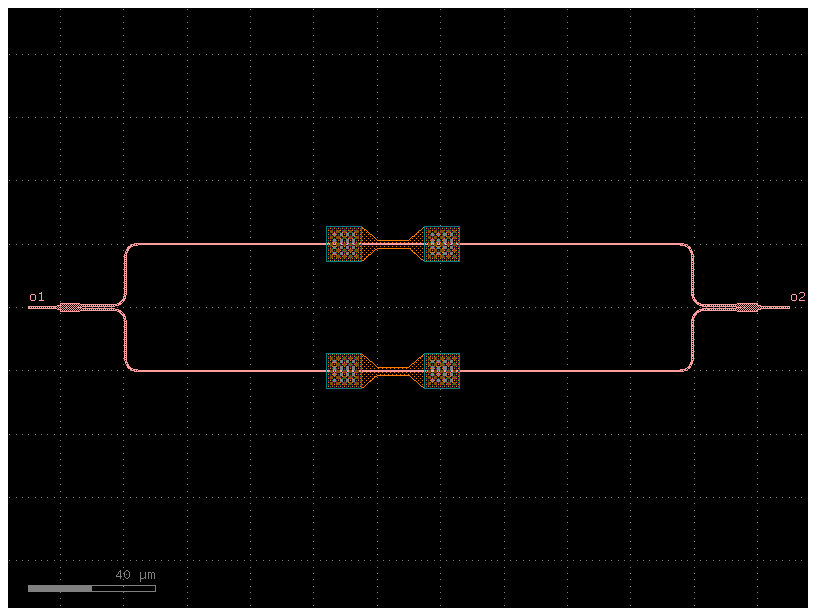

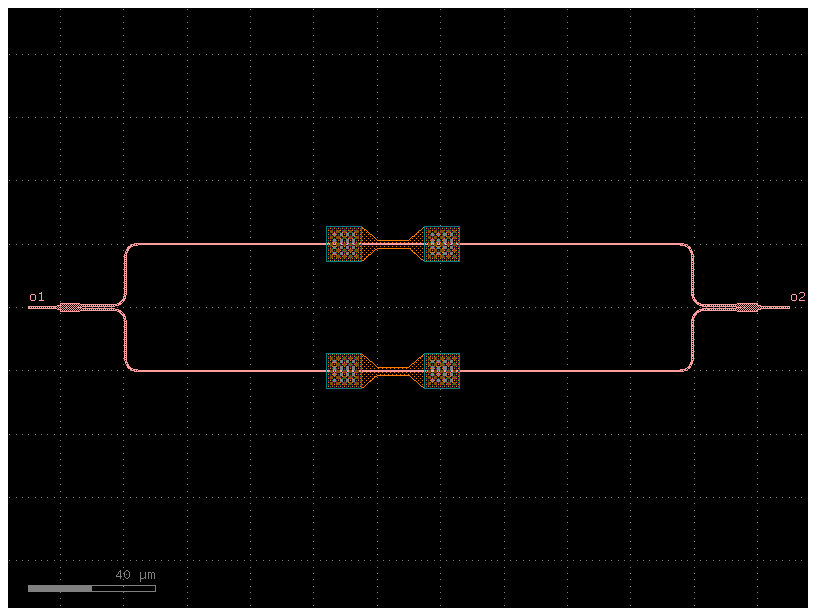

In [36]:
mzm_cell2()

## Non-Linear Sign Gate — Sample 0 - syntax error (using imaginary e ports)

In [37]:

import gdsfactory as gf

def nls_gate(phi=180):

    r = gf.Component()

    # Instantiate all components
    coupler1 = r.add_ref(gf.components.coupler())
    coupler2 = r.add_ref(gf.components.coupler())
    coupler3 = r.add_ref(gf.components.coupler())
    phase_shifter = r.add_ref(gf.components.straight_heater_metal(length=10))

    # Move parts to avoid overlap (DRC-safe)
    coupler2.move((100, 0))
    coupler3.move((200, 0))
    phase_shifter.move((150, 20))

    # Connect ports with route_single
    routings = [
        (coupler1.ports['o3'], coupler2.ports['o1']),
        (coupler1.ports['o4'], phase_shifter.ports['o1']),
        (phase_shifter.ports['o2'], coupler2.ports['o2']),
        (coupler2.ports['o3'], coupler3.ports['o1']),
        (coupler2.ports['o4'], coupler3.ports['o2']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)

    # Expose external ports
    r.add_port("o1", port=coupler1.ports["o1"])
    r.add_port("o2", port=coupler1.ports["o2"])
    r.add_port("o3", port=coupler3.ports["o3"])
    r.add_port("o4", port=coupler3.ports["o4"])
    r.add_port("o5", port=phase_shifter.ports["e1"])
    r.add_port("o6", port=phase_shifter.ports["e2"])

    r.draw_ports()
    r.plot()

    return r

In [38]:
nls_gate()

KeyError: "key='e1' is not a valid port name or index. Make sure the instance is an array when giving it a tuple. Available ports: ['o1', 'o2', 'l_e1', 'l_e2', 'l_e3', 'l_e4', 'r_e1', 'r_e2', 'r_e3', 'r_e4']"

## Non-Linear Sign Gate — Sample 1 - func error

In [40]:

import gdsfactory as gf

def nls_gate2(phi=180):

    r = gf.Component()

    # Instantiate all components
    coupler1 = r.add_ref(gf.components.coupler())
    coupler2 = r.add_ref(gf.components.coupler())
    coupler3 = r.add_ref(gf.components.coupler())
    phase_shifter = r.add_ref(gf.components.straight_heater_metal(length=10, cross_section='strip'))

    # Move parts to avoid overlap
    coupler1.move((0, 0))
    coupler2.move((100, 0))
    coupler3.move((200, 0))
    phase_shifter.move((150, 50))

    # Connect ports with route_single
    routings = [
        (coupler1.ports['o3'], coupler2.ports['o1']),
        (coupler1.ports['o4'], coupler2.ports['o2']),
        (coupler2.ports['o3'], phase_shifter.ports['o1']),
        (phase_shifter.ports['o2'], coupler3.ports['o1']),
        (coupler2.ports['o4'], coupler3.ports['o2']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)

    # Expose external ports
    r.add_port("o1", port=coupler1.ports["o1"])
    r.add_port("o2", port=coupler1.ports["o2"])
    r.add_port("o3", port=coupler3.ports["o3"])
    r.add_port("o4", port=coupler3.ports["o4"])

    r.draw_ports()
    r.plot()

    return r


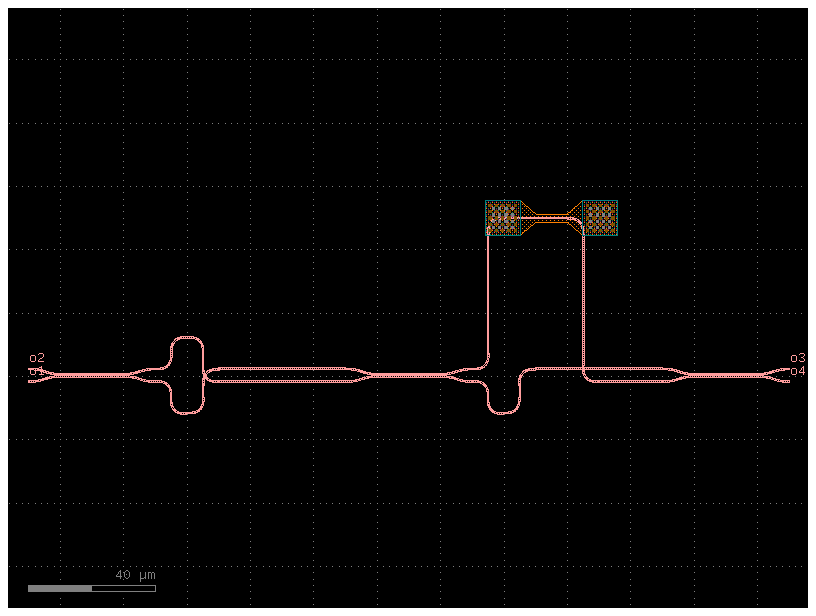

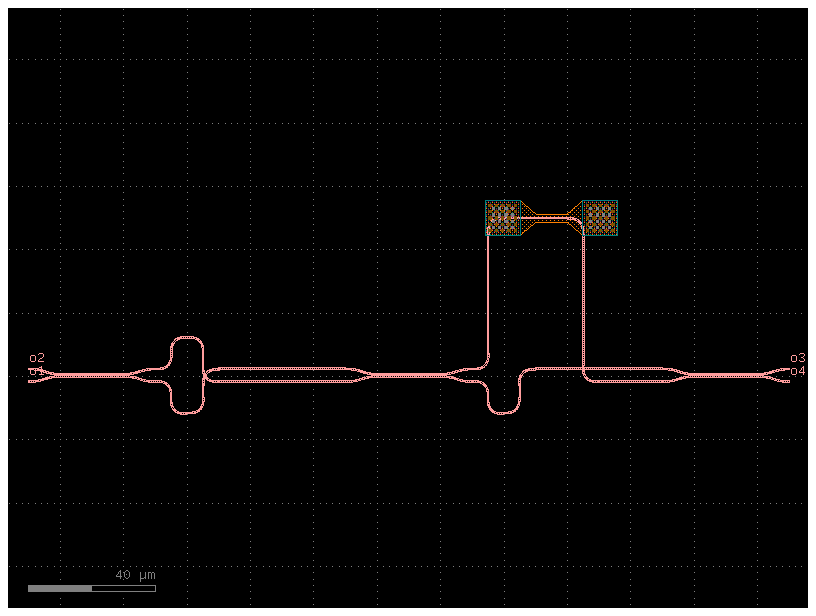

In [41]:
nls_gate2()

## Non-Linear Sign Gate — Sample 2 - func error

In [43]:

import gdsfactory as gf

def nls_gate2(phi=180):
    r = gf.Component()

    # 1. Instantiate all components (with settings)
    coupler1 = r.add_ref(gf.components.coupler())
    coupler2 = r.add_ref(gf.components.coupler())
    coupler3 = r.add_ref(gf.components.coupler())
    phase_shifter = r.add_ref(gf.components.straight_heater_metal(length=100))

    # 2. Move parts to avoid overlap (DRC-safe)
    coupler1.move((0, 0))
    coupler2.move((200, 0))
    coupler3.move((400, 0))
    phase_shifter.move((300, 100))

    # 3. Connect ports with route_single
    routings = [
        (coupler1.ports['o3'], coupler2.ports['o1']),
        (coupler1.ports['o4'], coupler2.ports['o2']),
        (coupler2.ports['o3'], phase_shifter.ports['o1']),
        (phase_shifter.ports['o2'], coupler3.ports['o1']),
        (coupler2.ports['o4'], coupler3.ports['o2']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip')

    # 4. Expose external ports
    r.add_port("o1", port=coupler1.ports["o1"])
    r.add_port("o2", port=coupler1.ports["o2"])
    r.add_port("o3", port=coupler3.ports["o3"])
    r.add_port("o4", port=coupler3.ports["o4"])

    r.draw_ports()
    r.plot()

    return r


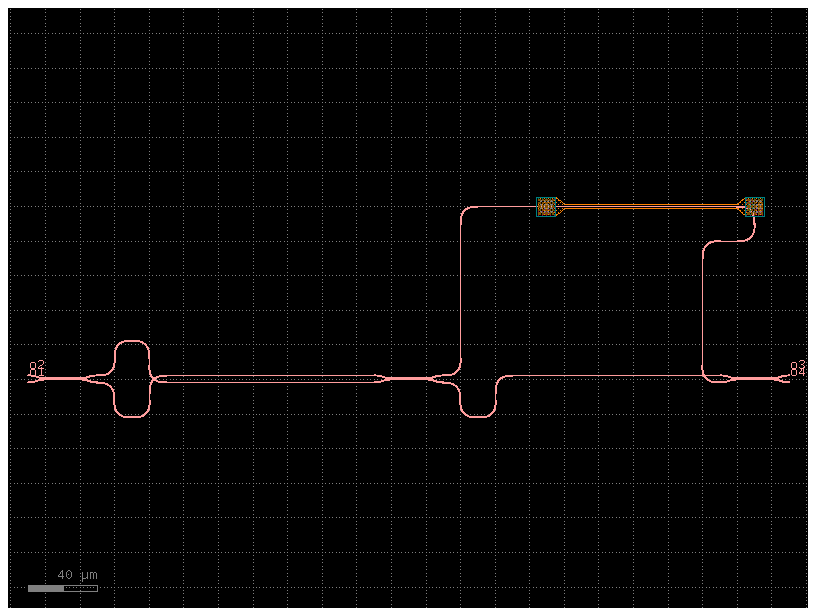

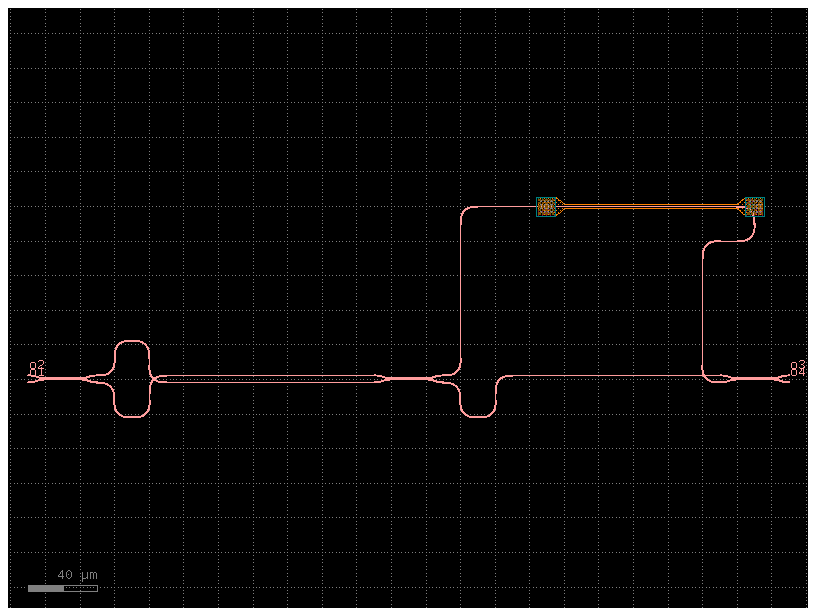

In [44]:
nls_gate2()